# Arm A — Global (Non-Stratified) Baseline

This notebook implements Arm A of the study: a single classifier trained on the full patient population without stratification. Arm A provides the baseline against which the sex-based clinical subgroups of Arm B and the k-prototypes clusters of Arm C are compared.

All three arms use the same features, the same two classifiers, the same preprocessing procedure, the same hyperparameter-selection procedure, the same evaluation protocol, and the same outer cross-validation fold partitions. The only intended difference between arms is the stratification strategy, so that any difference observed between arms can be attributed to how patient heterogeneity is handled rather than to differences in modelling conditions.

## 2. Imports and configuration

RANDOM_STATE is fixed so that every step involving randomness (fold assignment and model fitting) is reproducible: rerunning this notebook produces the same folds, the same hyperparameter choices, and the same results.

K_OUTER and K_INNER are both set to 5. The Cleveland subset is a small dataset (on the order of 300 patients), so 5 folds balances having enough patients per fold against having enough folds to average over. The outer folds provide the held-out data used to report performance; the inner folds are used only within each outer training fold to select hyperparameters, so hyperparameter selection never has access to the corresponding outer validation data.

In [1]:
import os
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection   import StratifiedKFold, GridSearchCV
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.metrics           import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    recall_score, confusion_matrix,
)

# Configuration
RANDOM_STATE = 2
K_OUTER      =  5
K_INNER      =  5

# Feature-selection toggle (used in Section 9): None keeps the full
# transformed feature set; an int (e.g. 8) enables a SelectKBest(f_classif)
# step inside each pipeline that keeps only the k strongest features.
FEATURE_SELECTION_K = None

# Path constants -- this notebook lives in notebooks/, so PROJECT_ROOT is
# one level up; all data and outputs are read/written relative to it.
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, "heart+disease")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
PREDICTIONS_DIR = os.path.join(RESULTS_DIR, "predictions")
DIAGNOSTICS_DIR = os.path.join(PROJECT_ROOT, "diagnostics")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(DIAGNOSTICS_DIR, exist_ok=True)

## 3. Load dataset

The modelling data is the cleaned Cleveland extract produced by data_cleaning.ipynb.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "cleveland_clean.csv"))
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (297, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,check
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,False
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,True
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,True
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,False
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,False


## 4. Target construction

The original Cleveland target, `num`, represents the presence/severity of heart disease. For binary classification, observations with `num = 0` are coded as class 0 (absence of disease), while observations with `num > 0` are coded as class 1 (presence of disease).

The dataset also contains a derived column, `check`, equal to `num > 0`. Because `check` is derived directly from the target, it is excluded from the feature matrix together with `num`: retaining a derived copy of the label as a feature would let the model see the answer instead of learning from the clinical features, which is a form of data leakage.

In [3]:
target_col = "num"

y = (df[target_col] > 0).astype(int)
X = df.drop(columns=[target_col, "check"], errors="ignore")

print("Samples:", len(df), " Features:", X.shape[1])
print("Class balance:")
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print("Positive rate: {:.3f}".format(y.mean()))

Samples: 297  Features: 13
Class balance:
num
no disease    160
disease       137
Name: count, dtype: int64
Positive rate: 0.461


## 5. Feature definition

Feature groupings (`continuous`, `nominal`, `binary`) and the `get_preprocessor()` helper that builds the shared `ColumnTransformer` are defined once in `data_cleaning.ipynb` and reused here via `%run`, so every arm applies identical preprocessing rather than each notebook keeping its own copy. Two changes from the previous version of this pipeline: `ca` (number of major vessels) is now standard-scaled as part of `continuous` rather than left as an unscaled passthrough count, and the nominal `OneHotEncoder` now uses `drop='first'` to remove the exact multicollinearity between its dummy columns.

In [4]:
%%capture
# get_preprocessor(), continuous, nominal, and binary are defined once in
# data_cleaning.ipynb and reused here (rather than redefined) so every arm
# applies identical preprocessing. %%capture suppresses that notebook's own
# printed output and plots so they don't clutter this notebook.
%run data_cleaning.ipynb

In [5]:
print("Continuous (standard-scaled):", continuous)
print("Nominal (one-hot encoded, drop='first'):", nominal)
print("Binary (passthrough):", binary)

Continuous (standard-scaled): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Nominal (one-hot encoded, drop='first'): ['cp', 'restecg', 'slope', 'thal']
Binary (passthrough): ['sex', 'fbs', 'exang']


## 6. Exploratory checks

The target classes are moderately balanced (approximately 54% vs 46%), so no class-balancing procedure is applied, consistent with the proposal.

num
no disease    160
disease       137
Name: count, dtype: int64

num
no disease    0.539
disease       0.461
Name: proportion, dtype: float64


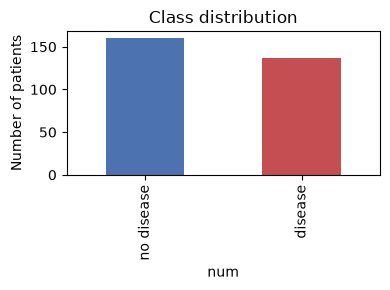

In [6]:
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print()
print(y.value_counts(normalize=True).rename({0: "no disease", 1: "disease"}).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().rename({0: "no disease", 1: "disease"}).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of patients")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

## 7. Preprocessing

The `ColumnTransformer` returned by `get_preprocessor()` (defined in `data_cleaning.ipynb`) is reused unchanged here. It is only ever fitted inside a `Pipeline` together with each classifier (Section 9), never on the full dataset: `GridSearchCV` refits the scaler and encoder separately on each training fold during cross-validation, so no information from the validation folds leaks into preprocessing.

In [7]:
# get_preprocessor() is imported from data_cleaning.ipynb (Section 5 above).
# It is only ever used inside a Pipeline (Section 9), fitted on
# training-fold data during cross-validation (Section 10) -- never fit here
# on the full dataset. This is just a sanity check on the transformed shape.
print("Preprocessed feature count (on full data, for inspection only):",
      get_preprocessor().fit_transform(X).shape[1])

Preprocessed feature count (on full data, for inspection only): 18


## 8. Fixed outer-fold construction

The proposal requires that all three arms are evaluated on the same outer cross-validation fold partitions (Section 3.5). Every patient is assigned a fold id once, stratified by the target, and the assignment is saved to `fold_id.csv`. If this file already exists, it is loaded and reused instead of being regenerated, so that Arm A, Arm B, and Arm C always evaluate the same patients in the same folds. `StratifiedKFold`, rather than a plain random split, is used because the classes are not perfectly balanced (160 vs 137), and stratification keeps the class ratio similar across folds. An MD5 hash of `fold_id.csv` is also written to `run_manifest.json`; Arm B and Arm C assert their loaded copy hashes to the same value, so a deleted, regenerated, or otherwise stale fold file is caught immediately rather than silently breaking comparability.

In [8]:
FOLD_FILE = os.path.join(PROJECT_ROOT, "fold_id.csv")

if os.path.exists(FOLD_FILE):
    fold_id = pd.read_csv(FOLD_FILE)["fold"].to_numpy()
    if len(fold_id) != len(df):
        raise ValueError(
            f"{FOLD_FILE} has {len(fold_id)} entries but the current dataset has {len(df)} rows; "
            "delete or regenerate the fold file before proceeding."
        )
    print(f"Loaded existing fold assignment from {FOLD_FILE}.")
else:
    skf = StratifiedKFold(n_splits=K_OUTER, shuffle=True, random_state=RANDOM_STATE)
    fold_id = np.empty(len(df), dtype=int)
    for k, (_, val_idx) in enumerate(skf.split(X, y)):
        fold_id[val_idx] = k
    pd.Series(fold_id, name="fold").to_csv(FOLD_FILE, index=False)
    print(f"Created new fold assignment and saved to {FOLD_FILE}.")

print("Fold sizes:", np.bincount(fold_id))
print("Positives per fold:", np.bincount(fold_id[y.values == 1]))

# Fold-file integrity guard (see Section 8): Arm B and Arm C assert against this hash.
fold_id_md5 = hashlib.md5(open(FOLD_FILE, "rb").read()).hexdigest()
MANIFEST_FILE = os.path.join(PROJECT_ROOT, "run_manifest.json")
with open(MANIFEST_FILE, "w") as f:
    json.dump({"fold_id_md5": fold_id_md5, "written_by": "global_model_armA.ipynb"}, f, indent=2)
print(f"fold_id.csv MD5: {fold_id_md5} (written to run_manifest.json)")

Loaded existing fold assignment from /Users/faye/Desktop/FIT2082/Research_heartDisease/FIT2082_Research/fold_id.csv.
Fold sizes: [60 60 59 59 59]
Positives per fold: [28 28 27 27 27]
fold_id.csv MD5: 4d54a69c577f498114826fb495d7eaa8 (written to run_manifest.json)


## 9. Model definitions and hyperparameter grids

Three classifiers are used: logistic regression (interpretable, linear), random forest (non-linear, tree-based), and a support vector classifier (linear or RBF kernel) as an additional comparator. Grids are kept small and are sized for a dataset this small (N ≈ 297 patients overall, so an inner-fold training split has roughly 190 patients):

- **Logistic regression**: `C` is searched over `np.logspace(-3, 2, 10)` (~0.001 to 100), with both l1 and l2 regularisation via the `liblinear` solver. As of scikit-learn 1.8, the `penalty="l1"/"l2"` strings are deprecated in favour of `l1_ratio` (`l1_ratio=0.0` = pure l2, `l1_ratio=1.0` = pure l1), which `liblinear` supports at both endpoints, so the grid searches `l1_ratio` instead -- the same two penalty types the old API expressed, without the deprecation warning.
- **Random forest**: `max_depth` is restricted to `[2, 3, 4, 5]`, `min_samples_leaf` to `[2, 4, 8]`, and `n_estimators` to `[50, 100]`. Shallow trees and larger leaf sizes are deliberate regularisation: with ~190 training patients per inner fold, deeper/unrestricted trees overfit rather than generalise.
- **SVM**: `C` is searched over a smaller `np.logspace(-3, 2, 6)` grid across `linear` and `rbf` kernels, with `gamma='scale'`. The estimator is wrapped in `CalibratedClassifierCV(SVC(), method='sigmoid', cv=5, ensemble=False)` rather than `SVC(probability=True)`, since the latter is deprecated as of scikit-learn 1.9; this keeps a `predict_proba` output (needed for ROC-AUC/PR-AUC scoring) without the deprecation warning.

Each pipeline optionally inserts a `SelectKBest(f_classif)` feature-selection step between preprocessing and the classifier, controlled by the `FEATURE_SELECTION_K` toggle set in Section 2: `None` keeps the full transformed feature set, while an integer (e.g. `8`) keeps only the k features with the strongest univariate (ANOVA F-test) association with the target -- which tends to drop the weakest ones, such as `fbs`.

The same classifiers, grids, and tuning procedure are intended to be reused unchanged in Arm B and Arm C, so that any difference between arms reflects the stratification strategy rather than the modelling choices.

In [9]:
def build_pipeline(estimator):
    """Chain the shared preprocessor, an optional feature-selection step,
    and a classifier. FEATURE_SELECTION_K (Section 2) toggles the
    SelectKBest step: None keeps every transformed feature; an int keeps
    only the k strongest by ANOVA F-value against the target."""
    steps = [("preprocessor", get_preprocessor())]
    if FEATURE_SELECTION_K is not None:
        steps.append(("select", SelectKBest(score_func=f_classif, k=FEATURE_SELECTION_K)))
    else:
        steps.append(("select", "passthrough"))
    steps.append(("clf", estimator))
    return Pipeline(steps)


models = {
    "logreg": (
        build_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        {
            "clf__C": np.logspace(-3, 2, 10),   # ~0.001 to 100, log-spaced
            # l1_ratio=0.0 -> pure l2, l1_ratio=1.0 -> pure l1. scikit-learn
            # 1.8+ deprecated the old penalty="l1"/"l2" strings in favour of
            # l1_ratio (liblinear supports both endpoints); this searches
            # the same two penalty types the old API did.
            "clf__l1_ratio": [0.0, 1.0],
            "clf__solver": ["liblinear"],        # supports both l1 and l2 penalties
        },
    ),
    "rf": (
        build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
        {
            "clf__max_depth": [2, 3, 4, 5],       # shallow trees: N~297 overfits deeper ones
            "clf__min_samples_leaf": [2, 4, 8],
            "clf__n_estimators": [50, 100],
        },
    ),
    "svm": (
        # SVC(probability=True) is deprecated as of scikit-learn 1.9;
        # CalibratedClassifierCV(SVC(), ensemble=False) is the replacement
        # scikit-learn itself recommends for a predict_proba-compatible SVM.
        build_pipeline(CalibratedClassifierCV(
            SVC(random_state=RANDOM_STATE), method="sigmoid", cv=5, ensemble=False,
        )),
        {
            "clf__estimator__C": np.logspace(-3, 2, 6),
            "clf__estimator__kernel": ["linear", "rbf"],
            "clf__estimator__gamma": ["scale"],
        },
    ),
}

## 10. Nested cross-validation

For each model and each outer fold, hyperparameters are selected using `GridSearchCV` with an inner stratified cross-validation on the training portion of that fold only; the outer validation fold is never used during hyperparameter selection. ROC-AUC is used as the tuning criterion (`scoring="roc_auc"`) because it is threshold-independent. Accuracy, F1-score, ROC-AUC, PR-AUC (average precision), sensitivity (recall on the positive/disease class), and specificity (recall on the negative/no-disease class) are then computed on the held-out outer fold using the selected hyperparameters. Predicted class labels use a fixed probability threshold of 0.5, applied identically in every fold, model, and arm, so that thresholding does not become a source of variation between arms.

In [10]:
fold_results = []
oof_rows = []
patient_id = df.index.to_numpy()

for name, (pipe, grid) in models.items():
    for k in range(K_OUTER):
        train, validation = (fold_id != k), (fold_id == k)

        # Hyperparameter selection uses only the training portion of this outer
        # fold; the outer validation fold is not seen until scoring below.
        inner = StratifiedKFold(n_splits=K_INNER, shuffle=True, random_state=RANDOM_STATE)
        search = GridSearchCV(pipe, grid, cv=inner, scoring="roc_auc", n_jobs=-1)
        search.fit(X[train], y[train])

        best = search.best_estimator_
        proba = best.predict_proba(X[validation])[:, 1]  # Predicted probability of the positive class (heart disease)
        pred  = (proba >= 0.5).astype(int)                # Fixed threshold, held constant across arms

        y_val = y[validation].to_numpy()
        # Specificity (true-negative rate) has no dedicated sklearn scorer,
        # so it's derived from the confusion matrix; sensitivity is the
        # standard recall on the positive class.
        tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        fold_results.append({
            "model": name,
            "fold": k,
            "accuracy": accuracy_score(y_val, pred),
            "f1": f1_score(y_val, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val, proba),
            "pr_auc": average_precision_score(y_val, proba),
            "sensitivity": recall_score(y_val, pred, zero_division=0),
            "specificity": specificity,
            "best_params": search.best_params_,
        })

        for pid, yt, p, c in zip(patient_id[validation], y_val, proba, pred):
            oof_rows.append({
                "patient_id": int(pid), "fold": int(k), "y_true": int(yt),
                "model": name, "proba": float(p), "pred": int(c),
            })

fold_results_df = pd.DataFrame(fold_results)
print("Nested cross-validation complete:", len(fold_results_df), "model x fold rows")

Nested cross-validation complete: 15 model x fold rows


## 11. Fold-level results

Individual outer-fold metrics are retained, in addition to the summary statistics in the next section, so that Arm B and Arm C can later be compared fold-by-fold rather than only through aggregate means.

In [11]:
fold_results_display = fold_results_df.drop(columns=["best_params"]).round(3)
fold_results_df.to_csv(os.path.join(RESULTS_DIR, "armA_fold_results.csv"), index=False)
print("Saved armA_fold_results.csv")
fold_results_display

Saved armA_fold_results.csv


,model,fold,accuracy,f1,roc_auc,pr_auc,sensitivity,specificity
0,logreg,0,0.900,0.893,0.943,0.930,0.893,0.906
1,logreg,1,0.833,0.815,0.903,0.880,0.786,0.875
2,logreg,2,0.746,0.727,0.832,0.842,0.741,0.750
3,logreg,3,0.814,0.784,0.878,0.880,0.741,0.875
4,logreg,4,0.797,0.769,0.926,0.927,0.741,0.844
5,rf,0,0.883,0.877,0.948,0.946,0.893,0.875
6,rf,1,0.817,0.792,0.920,0.907,0.750,0.875
7,rf,2,0.729,0.692,0.810,0.798,0.667,0.781
8,rf,3,0.814,0.784,0.898,0.901,0.741,0.875
9,rf,4,0.847,0.809,0.953,0.950,0.704,0.969


## 12. Overall performance summary

Mean and standard deviation across the 5 outer folds are reported for each model, rather than a single point estimate, so that both average performance and its variability across folds can be assessed.

In [12]:
metric_cols = ["accuracy", "f1", "roc_auc", "pr_auc", "sensitivity", "specificity"]

results = (
    fold_results_df
    .groupby("model")[metric_cols]
    .agg(["mean", "std"])
)
results.columns = [f"{metric}_{stat}" for metric, stat in results.columns]
results = results.reset_index()

for _, row in results.iterrows():
    print(f"{row['model']:7s}"
          f" | ACC {row['accuracy_mean']:.3f} +/- {row['accuracy_std']:.3f}"
          f" | F1 {row['f1_mean']:.3f} +/- {row['f1_std']:.3f}"
          f" | ROC-AUC {row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}"
          f" | PR-AUC {row['pr_auc_mean']:.3f} +/- {row['pr_auc_std']:.3f}"
          f" | Sens {row['sensitivity_mean']:.3f} +/- {row['sensitivity_std']:.3f}"
          f" | Spec {row['specificity_mean']:.3f} +/- {row['specificity_std']:.3f}")

results.to_csv(os.path.join(RESULTS_DIR, "armA_results.csv"), index=False)
print("Saved armA_results.csv")
results.set_index("model").round(3)

logreg  | ACC 0.818 +/- 0.056 | F1 0.798 +/- 0.062 | ROC-AUC 0.897 +/- 0.043 | PR-AUC 0.892 +/- 0.037 | Sens 0.780 +/- 0.066 | Spec 0.850 +/- 0.060
rf      | ACC 0.818 +/- 0.057 | F1 0.791 +/- 0.066 | ROC-AUC 0.906 +/- 0.058 | PR-AUC 0.901 +/- 0.061 | Sens 0.751 +/- 0.086 | Spec 0.875 +/- 0.066
svm     | ACC 0.838 +/- 0.050 | F1 0.813 +/- 0.061 | ROC-AUC 0.902 +/- 0.044 | PR-AUC 0.897 +/- 0.040 | Sens 0.773 +/- 0.089 | Spec 0.894 +/- 0.036
Saved armA_results.csv


,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std
model,,,,,,,,,,,,
logreg,0.818,0.056,0.798,0.062,0.897,0.043,0.892,0.037,0.780,0.066,0.850,0.060
rf,0.818,0.057,0.791,0.066,0.906,0.058,0.901,0.061,0.751,0.086,0.875,0.066
svm,0.838,0.050,0.813,0.061,0.902,0.044,0.897,0.040,0.773,0.089,0.894,0.036


## 13. Out-of-fold predictions

For every patient, the out-of-fold prediction from the one outer fold in which they were held out is retained, together with the patient identifier, fold id, true label, model name, predicted probability, and predicted class. This per-patient record is what allows Arm A, Arm B, and Arm C to be compared on identical patients rather than only through aggregate metrics.

In [13]:
oof_df = pd.DataFrame(oof_rows)
oof_df.to_csv(os.path.join(PREDICTIONS_DIR, "armA_predictions.csv"), index=False)
print("Saved armA_predictions.csv:", oof_df.shape)
oof_df.head()

Saved armA_predictions.csv: (891, 6)


,patient_id,fold,y_true,model,proba,pred
0,1,0,1,logreg,0.988758,1
1,2,0,1,logreg,0.985746,1
2,6,0,1,logreg,0.792320,1
3,8,0,1,logreg,0.898119,1
4,10,0,0,logreg,0.402325,0


## 14. Interpretation / notes

Three models (logistic regression, random forest, SVM) are compared; Arm A's purpose is to provide a comparison baseline rather than to select a single preferred classifier.

Preprocessing changes from the previous version of this notebook (now defined once in `data_cleaning.ipynb` and imported here):

- `ca` is standard-scaled as part of `continuous` rather than left as an unscaled passthrough count.
- The nominal `OneHotEncoder` now uses `drop='first'`, removing the exact multicollinearity between dummy columns that the previous full one-hot encoding produced.
- An optional `SelectKBest(f_classif)` step (`FEATURE_SELECTION_K`, Sections 2 and 9) can reduce the transformed feature set, e.g. to 8 features, to test whether dropping low-power features such as `fbs` changes performance.

For comparability with Arm B and Arm C:

- If these preprocessing changes are adopted project-wide, Arm B and Arm C should import the same `continuous`/`nominal`/`binary` groupings and `get_preprocessor()` from `data_cleaning.ipynb` rather than keep their own local `passthrough`-based definitions, so all three arms stay aligned on feature representation. Arm B's existing exception of dropping `sex` from its subgroup feature matrix, and Arm C's additional standardisation of the passthrough block for clustering, are unaffected by this and remain arm-specific as previously documented.
- `fold_id.csv`, created in Section 8, should continue to be loaded by Arm B and Arm C rather than regenerated, so all arms evaluate the same patients in the same folds.
- Arm C's k-prototypes clustering must still be fitted using only the training portion of each outer fold, so cluster assignment does not leak validation-fold information; this notebook does not perform any clustering or stratification, consistent with Arm A's role as the non-stratified baseline.